# Importing all essential libraries!

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (f1_score, accuracy_score, precision_score, classification_report, ConfusionMatrixDisplay, r2_score, recall_score)

print("All required libraries imported successfully!")

All required libraries imported successfully!


# Download dataset from kaggle

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")

print("Path to dataset files:", path)

Path to dataset files: /home/sushant/.cache/kagglehub/datasets/saurabhshahane/fake-news-classification/versions/77


In [6]:
import os
print(os.listdir(path))

['WELFake_Dataset.csv']


# Now load a dataset 


In [7]:
df = pd.read_csv(os.path.join(path, 'WELFake_Dataset.csv'))

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [8]:
df.head(10)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1
6,6,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1
7,7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1
8,8,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",1
9,9,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",1


In [9]:
df.tail(10)

,Unnamed: 0,title,text,label
72124,72124,An Unlikely Contender Rises in France as the A...,"PARIS — In the age of Donald J. Trump, “Bre...",0
72125,72125,WOW! JILL STEIN’S ‘FIRESIDE CHAT’ Exposes Her ...,,1
72126,72126,Determined to kill: Can tough gun laws end mas...,The flag at Desert Hot Springs' Condor Gun Sho...,0
72127,72127,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1
72128,72128,JUDGE JEANINE SOUNDS FREE SPEECH ALARM: “They ...,Judge Jeanine lets it rip! She s concerned wit...,1
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


# As you see a label column showing 0 and 1

- `Real NEWS` -> 1
- `Fake NEWS` -> 0

In [10]:
rows = df.shape[0]
columns = df.shape[1]

print(f"Rows is {rows} and columns is {columns}")

Rows is 72134 and columns is 4


In [11]:
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [12]:
df.dtypes

Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [14]:
df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


# Visualization 

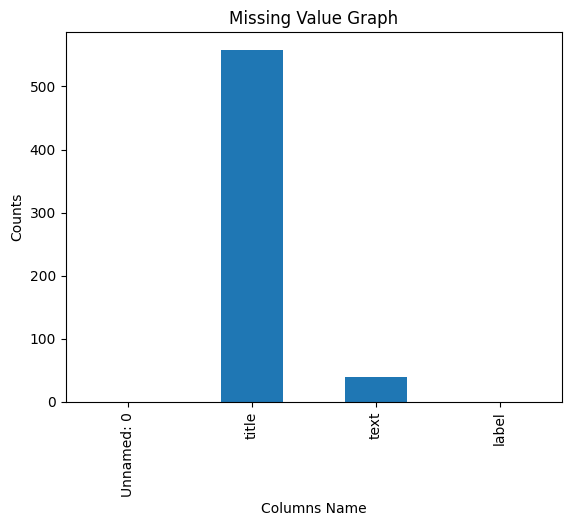

In [15]:
graph = df.isnull().sum()
graph.plot(kind='bar')
plt.title("Missing Value Graph")
plt.xlabel("Columns Name")
plt.ylabel("Counts")
plt.show()

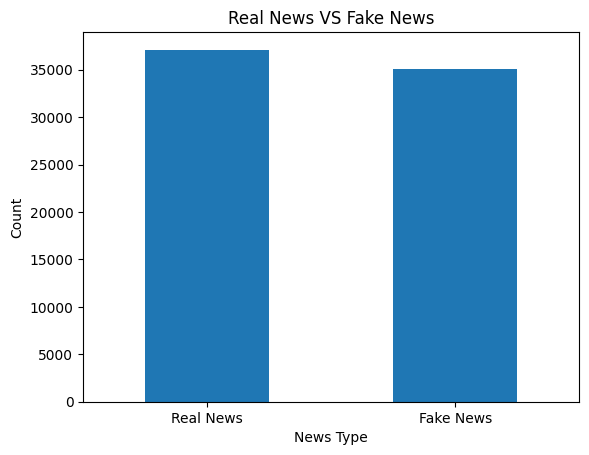

In [16]:
label_counts = df["label"].value_counts().plot(kind='bar')
plt.title("Real News VS Fake News")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.xticks([0,1], ['Real News', 'Fake News'],rotation=0)
plt.show()

# Filling Null Value

In [17]:
text_columns = ['title', 'text']

for col in text_columns:
    df[col] = df[col].fillna(" ")

In [18]:
df.isnull().sum()

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

# Duplicate Value in dataset

In [19]:
df.duplicated().sum()

np.int64(0)

# Text Preprocessing

In [20]:
import re

def clean_text(text):
    text = text.lower()                         # Lowercase
    text = re.sub(r"http\S+", "", text)         # Remove URLs
    text = re.sub(r"<.*?>", "", text)           # Remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # Remove numbers & punctuation
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    return text

# Join input value in single column

You have two method to join two or more columns

- `1st Method` -> df['content'] = df['title'] + " " + df['text'] + " " +......+df['xyz']
- `2nd Method` -> As you see in the below

In [21]:
df['content'] = df[text_columns].agg(' '.join, axis=1)

In [22]:
df['content'] = df['content'].apply(clean_text)

In [23]:
df['content'].head()

0    law enforcement on high alert following threat...
1        did they post their votes for hillary already
2    unbelievable obama s attorney general says mos...
3    bobby jindal raised hindu uses story of christ...
4    satan russia unvelis an image of its terrifyin...
Name: content, dtype: object

In [24]:
print(df['content'].iloc[0])

law enforcement on high alert following threats against cops and whites on by blacklivesmatter and fyf terrorists video no comment is expected from barack obama members of the fyf or fukyoflag and blacklivesmatter movements called for the lynching and hanging of white people and cops they encouraged others on a radio show tuesday night to turn the tide and kill white people and cops to send a message about the killing of black people in america one of the f yoflag organizers is called sunshine she has a radio blog show hosted from texas called sunshine s f ing opinion radio show a snapshot of her fyf lolatwhitefear twitter page at p m shows that she was urging supporters to call now fyf tonight we continue to dismantle the illusion of white below is a snapshot twitter radio call invite fyf the radio show aired at p m eastern standard time during the show callers clearly call for lynching and killing of white people a minute clip from the radio show can be heard here it was provided to 

# Initializing value of the X and y for train test split

In [25]:
X = df['content']
y = df['label']

# Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train Data is {X_train.shape}')
print(f'Test Data is {X_test.shape}')

Train Data is (57707,)
Test Data is (14427,)


# Convert string value to interger value

In [27]:
tfidf = TfidfVectorizer(max_features=50000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [28]:
print(f'Train Data is {X_train_tfidf.shape}')
print(f'Test Data is {X_test_tfidf.shape}')

Train Data is (57707, 50000)
Test Data is (14427, 50000)


# Model Implementation

### `Model 1` -> LogisticRegression

In [29]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
print("Logistic Regression Trained Successfully!")

Logistic Regression Trained Successfully!


In [30]:
y_pred_lr_model = lr_model.predict(X_test_tfidf)

In [31]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr_model))
print("Precision Score :", precision_score(y_test, y_pred_lr_model))
print("F1 Score :", f1_score(y_test, y_pred_lr_model))
print("R2 Score :", r2_score(y_test, y_pred_lr_model))
print("Recall Score :", recall_score(y_test, y_pred_lr_model))
print("Classification report :\n\n", classification_report(y_test, y_pred_lr_model))


Accuracy : 0.9514798641436196
Precision Score : 0.9464594127806563
F1 Score : 0.9531709927749532
R2 Score : 0.8057587307593164
Recall Score : 0.9599784395634011
Classification report :

               precision    recall  f1-score   support

           0       0.96      0.94      0.95      7006
           1       0.95      0.96      0.95      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427



### `Model 2` -> PassiveAggressiveClassifier

In [32]:
pac_model = PassiveAggressiveClassifier()
pac_model.fit(X_train_tfidf, y_train)
print("Passive Aggressive Classifier Trained Successfully!")

Passive Aggressive Classifier Trained Successfully!


In [33]:
y_pred_pac_model = pac_model.predict(X_test_tfidf)

In [34]:
print("Accuracy :", accuracy_score(y_test, y_pred_pac_model))
print("Precision Score :", precision_score(y_test, y_pred_pac_model))
print("F1 Score :", f1_score(y_test, y_pred_pac_model))
print("R2 Score :", r2_score(y_test, y_pred_pac_model))
print("Recall Score :", recall_score(y_test, y_pred_pac_model))
print("Classification report :\n\n", classification_report(y_test, y_pred_pac_model))


Accuracy : 0.9674221944964303
Precision Score : 0.9633382215704572
F1 Score : 0.9685028816512532
R2 Score : 0.8695808620812553
Recall Score : 0.9737232178951624
Classification report :

               precision    recall  f1-score   support

           0       0.97      0.96      0.97      7006
           1       0.96      0.97      0.97      7421

    accuracy                           0.97     14427
   macro avg       0.97      0.97      0.97     14427
weighted avg       0.97      0.97      0.97     14427



### `Model 3` -> LinearSVC


In [35]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
print("Linear SVC Trained Successfully!")

Linear SVC Trained Successfully!


In [36]:
y_pred_svm_model = svm_model.predict(X_test_tfidf)

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm_model))
print("Precision Score :", precision_score(y_test, y_pred_svm_model))
print("F1 Score :", f1_score(y_test, y_pred_svm_model))
print("R2 Score :", r2_score(y_test, y_pred_svm_model))
print("Recall Score :", recall_score(y_test, y_pred_svm_model))
print("Classification report :\n\n", classification_report(y_test, y_pred_svm_model))


Accuracy : 0.9690857420115062
Precision Score : 0.9639483836636956
F1 Score : 0.9701432588030526
R2 Score : 0.8762405627409359
Recall Score : 0.9764182724700176
Classification report :

               precision    recall  f1-score   support

           0       0.97      0.96      0.97      7006
           1       0.96      0.98      0.97      7421

    accuracy                           0.97     14427
   macro avg       0.97      0.97      0.97     14427
weighted avg       0.97      0.97      0.97     14427



### `Model 4` -> MultinomialNB / Naive Bayes


In [38]:
naiveB_model = MultinomialNB()
naiveB_model.fit(X_train_tfidf, y_train)
print("MultinomialNB ( Naive Bayes ) Trained Successfully!")

MultinomialNB ( Naive Bayes ) Trained Successfully!


In [39]:
y_pred_naiveB_model = naiveB_model.predict(X_test_tfidf)

In [40]:
print("Accuracy :", accuracy_score(y_test, y_pred_naiveB_model))
print("Precision Score :", precision_score(y_test, y_pred_naiveB_model))
print("F1 Score :", f1_score(y_test, y_pred_naiveB_model))
print("R2 Score :", r2_score(y_test, y_pred_naiveB_model))
print("Recall Score :", recall_score(y_test, y_pred_naiveB_model))
print("Classification report :\n\n", classification_report(y_test, y_pred_naiveB_model))


Accuracy : 0.8755111942884869
Precision Score : 0.8672150411280846
F1 Score : 0.8809018567639257
R2 Score : 0.5016324006339032
Recall Score : 0.8950276243093923
Classification report :

               precision    recall  f1-score   support

           0       0.88      0.85      0.87      7006
           1       0.87      0.90      0.88      7421

    accuracy                           0.88     14427
   macro avg       0.88      0.87      0.88     14427
weighted avg       0.88      0.88      0.88     14427



# Comparing all four model testing

In [41]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Passive Aggressive Classifier': PassiveAggressiveClassifier(),
    'Linear SVM': LinearSVC(),
    'Naive Bayes': MultinomialNB()
}

result = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    
    y_pred_model = model.predict(X_test_tfidf)
    
    result.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_model),
        'Precision': precision_score(y_test, y_pred_model),
        'Recall': recall_score(y_test, y_pred_model),
        'F1 Score': f1_score(y_test, y_pred_model)
    })
    
result_df = pd.DataFrame(result)

print(result_df)

                           Model  Accuracy  Precision    Recall  F1 Score
0            Logistic Regression  0.951480   0.946459  0.959978  0.953171
1  Passive Aggressive Classifier  0.968254   0.966626  0.971837  0.969225
2                     Linear SVM  0.969086   0.963948  0.976418  0.970143
3                    Naive Bayes  0.875511   0.867215  0.895028  0.880902


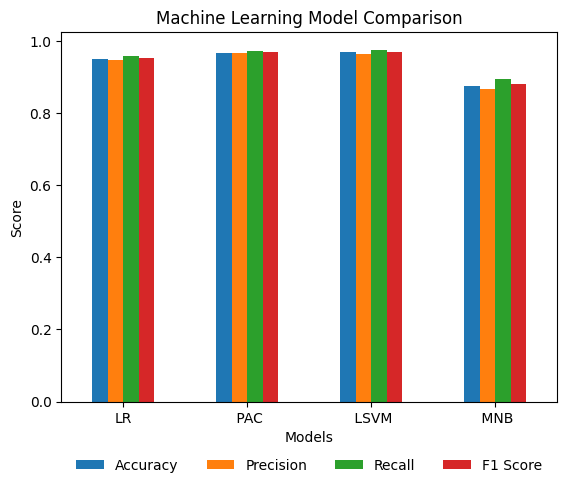

In [42]:
result_df.plot(kind='bar')
plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks([0,1,2,3], ["LR" ," PAC"," LSVM"," MNB"], rotation=0)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False
)
plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

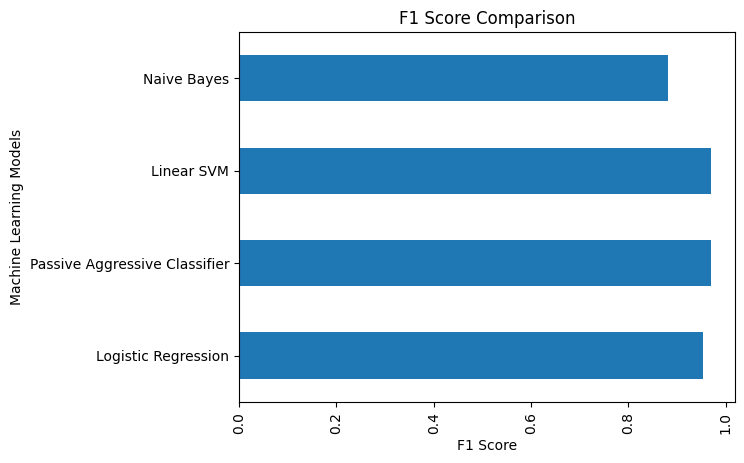

In [43]:
result_df.plot(
    x="Model",
    y="F1 Score",
    kind="barh",
    legend=False
)

plt.title("F1 Score Comparison")
plt.ylabel("Machine Learning Models")
plt.xlabel("F1 Score")
plt.xticks(rotation=90)

plt.show()

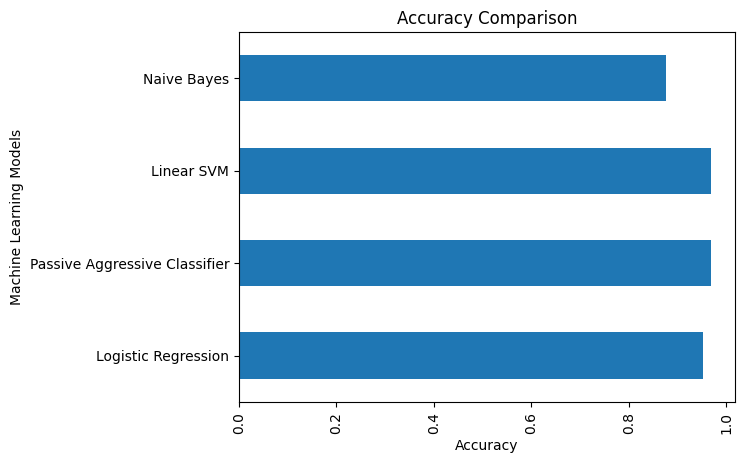

In [44]:
result_df.plot(
    x='Model',
    y='Accuracy',
    kind='barh',
    legend=False
)
plt.title("Accuracy Comparison")
plt.ylabel("Machine Learning Models")
plt.xlabel("Accuracy")
plt.xticks(rotation=90)
plt.show()

In [45]:
best_model = result_df.iloc[result_df['F1 Score'].idxmax()]
print("Best Model name is", best_model['Model'])
print("Best F1 Score is", best_model['F1 Score'])

Best Model name is Linear SVM
Best F1 Score is 0.9701432588030526


# Confusion Matrix

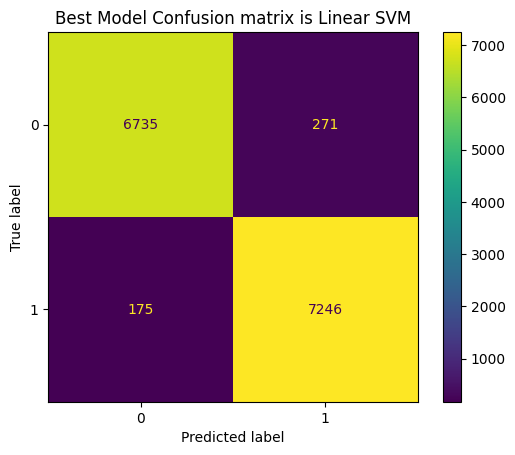

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_model)
plt.title(f"Best Model Confusion matrix is {best_model['Model']}")
plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [47]:
import pickle

with open("../model/model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("../model/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# User Predication System

In [48]:
def predict_news(text):
    
    text = clean_text(text)
    text_tfidf = tfidf.transform([text])
    predication = svm_model.predict(text_tfidf)

    if predication[0] == 1:
        return "Real News"
    else:
        return "Fake News"

In [49]:
news = """The government today announced a nationwide renewable energy initiative aimed at increasing the country's use of solar and wind power over the next decade. 
Officials said the program includes financial incentives for businesses investing in clean energy technologies, expanded support for residential solar panel 
installations, and funding for research into energy storage systems. According to the Ministry of Energy, the initiative is expected to reduce carbon emissions 
while creating thousands of new jobs in the renewable energy sector. Industry experts welcomed the announcement, stating that long-term investment in sustainable
energy infrastructure will help improve energy security and support economic growth."""
print(predict_news(news))

Real News


In [50]:
jh = """The city administration has officially inaugurated a new public health center to improve access to healthcare services for local residents.
The facility offers general medical consultations, maternal and child healthcare, vaccination programs, diagnostic testing, and emergency care. 
During the inauguration ceremony, local officials stated that the center is equipped with modern medical equipment and trained healthcare 
professionals to provide quality treatment. The project was funded through a government healthcare initiative aimed at strengthening public
health infrastructure. Residents welcomed the opening of the center, saying
it will reduce travel time and improve access to essential medical services."""
print(predict_news(jh))

Fake News
